# Bank Customer Conversion Optimization
## Data Import, Profiling & Validation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#load dataset
df = pd.read_csv("bank-additional-full.csv", 
                 sep=";",          # use semicolon as delimiter
                 quotechar='"')    # handle quoted column names
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
#quick dataset checks
#shape of the dataset
print(f"Shape of dataset: {df.shape}")
#clean column names
print(f"List of columns: {df.columns}")

Shape of dataset: (41188, 21)
List of columns: Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')


In [4]:
#check for nulls
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [5]:
#check for duplicate values
df.duplicated().sum()

np.int64(12)

In [6]:
#drop duplicated rows
df = df.drop_duplicates()

In [7]:
#confirm duplicate removal
print(df.duplicated().sum())  
print(df.shape)                # new row count

0
(41176, 21)


In [8]:
#validate data types
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [9]:
#validate consistency of categorical values
#list of categorical columns
categorical_cols = [
    'job','marital','education','default','housing','loan',
    'contact','month','day_of_week','poutcome','y'
]

# Validate consistency
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"  Unique categories: {df[col].unique()}")
    print(f"  Count per category:\n{df[col].value_counts()}")


Column: job
  Unique categories: <ArrowStringArray>
[    'housemaid',      'services',        'admin.',   'blue-collar',
    'technician',       'retired',    'management',    'unemployed',
 'self-employed',       'unknown',  'entrepreneur',       'student']
Length: 12, dtype: str
  Count per category:
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Column: marital
  Unique categories: <ArrowStringArray>
['married', 'single', 'divorced', 'unknown']
Length: 4, dtype: str
  Count per category:
marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64

Column: education
  Unique categories: <ArrowStringArray>
[           'basic.4y',         'high.school',            'basic.6y',
        

## Data Analysis

In [10]:
#performance baseline
#what is the overall conversion rate?
conversion_rate = df['y'].eq('yes').mean() * 100
total_contacts = len(df)
total_conversions = df['y'].eq('yes').sum()

print(f"Total Contacts: {total_contacts}")
print(f"Total Conversions: {total_conversions}")
print(f"Conversion Rate: {conversion_rate:.2f}%")

Total Contacts: 41176
Total Conversions: 4639
Conversion Rate: 11.27%


In [11]:
# ---------------------------------------------
# reusable function to compute conversion rates across any categorical feature
# ---------------------------------------------

def conversion_by_feature(df, col):
    result = (
        df.groupby(col)['y']
        .apply(lambda x: (x == 'yes').mean() * 100)
        .round(2)
        .sort_values(ascending=False)
    )
    return result

In [12]:
#conversion by demographics
#identify who is more likely to convert?
#what are conversion rates by job, marital status, and education? Which groups show higher or lower likelihood of subscribing? 

print("Conversion by Job, Marital Status, and Education")

print("Conversion by Job")
print(conversion_by_feature(df, 'job'))

print("\nConversion by Marital Status")
print(conversion_by_feature(df, 'marital'))

print("\nConversion by Education")
print(conversion_by_feature(df, 'education'))

Conversion by Job, Marital Status, and Education
Conversion by Job
job
student          31.43
retired          25.26
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.90
Name: y, dtype: float64

Conversion by Marital Status
marital
unknown     15.00
single      14.01
divorced    10.32
married     10.16
Name: y, dtype: float64

Conversion by Education
education
illiterate             22.22
unknown                14.51
university.degree      13.72
professional.course    11.35
high.school            10.84
basic.4y               10.25
basic.6y                8.21
basic.9y                7.82
Name: y, dtype: float64


In [13]:
#financial context
#does debt impact conversion?
#specifically, do clients with active or defaulted convert less often compared to those without debt?

#create loan status feature
df['loan_status'] = np.select(
    [
        df['loan'] == 'no',
        df['loan'] == 'yes'
    ],
    [
        'No Loan',
        'Has Loan'
    ],
    default='Unknown'
)

#does having a loan affect conversion?
loan_vs_no = round(df.groupby('loan_status')['y'].apply(lambda x: (x == 'yes').mean() * 100), 2)
print(f"\nConversion rates of those with loans vs. those without: \n {loan_vs_no}")

#of those with loans, what are conversion rates of active loan holders vs. defaulters
loan_holders = df[df['loan'] == 'yes']
loan_default_analysis = round(loan_holders.groupby('default')['y'].apply(
    lambda x: (x == 'yes').mean() * 100), 2
)

print(f"\nconversion rates of those active loans vs. defaulters: \n {loan_default_analysis}")


Conversion rates of those with loans vs. those without: 
 loan_status
Has Loan    10.93
No Loan     11.34
Unknown     10.81
Name: y, dtype: float64

conversion rates of those active loans vs. defaulters: 
 default
no         12.52
unknown     4.72
Name: y, dtype: float64


In [14]:
#campaign execution
#which contact channel is more effective for conversion?

conv_rate_contact = conversion_by_feature(df, 'contact')
conv_rate_contact

contact
cellular     14.74
telephone     5.23
Name: y, dtype: float64

In [15]:
#when are campaigns more effective?
#how do conversion rates vary by month and day of week? 
#are certain months or weekdays more successful?

#define correct order for months and weekdays
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
weekday_order = ['mon','tue','wed','thu','fri']

#conversion by month
conv_by_month = conversion_by_feature(df, 'month').reindex(month_order)

print(f"\n Conversion by Month: \n {conv_by_month}")


 Conversion by Month: 
 month
jan      NaN
feb      NaN
mar    50.55
apr    20.49
may     6.44
jun    10.51
jul     9.04
aug    10.61
sep    44.91
oct    43.93
nov    10.15
dec    48.90
Name: y, dtype: float64


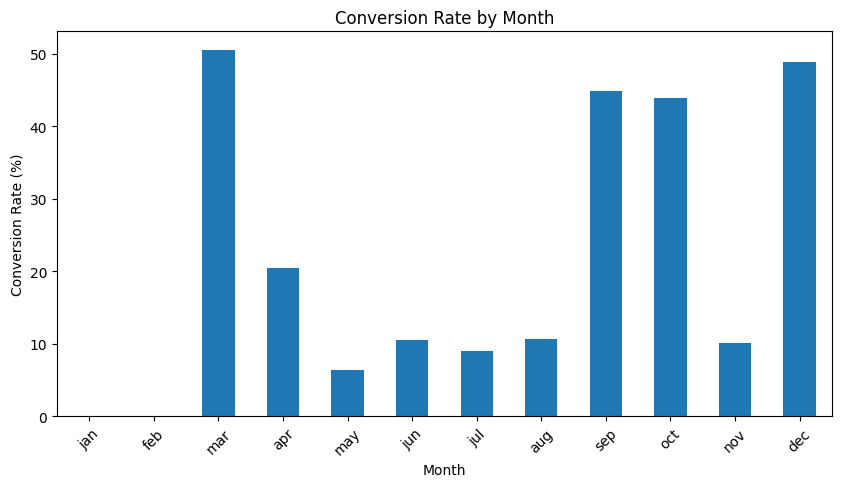

In [16]:
#visualize conversion rates by month
plt.figure(figsize=(10,5))
conv_by_month.plot(kind='bar')
plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

In [17]:
#conversion by day of week
conv_by_day = conversion_by_feature(df, 'day_of_week').reindex(weekday_order)

print(f"\n Conversion by Day of Week: \n {conv_by_day}")


 Conversion by Day of Week: 
 day_of_week
mon     9.95
tue    11.79
wed    11.67
thu    12.11
fri    10.81
Name: y, dtype: float64


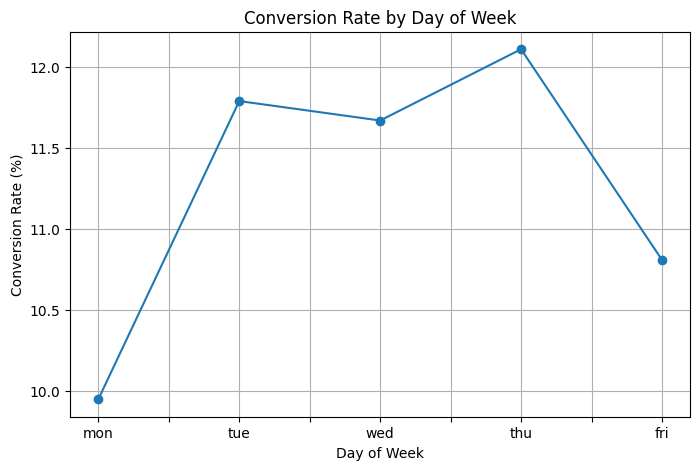

In [18]:
#visualize conversion rates by day of week
plt.figure(figsize=(8,5))
conv_by_day.plot(kind='line', marker='o')
plt.title("Conversion Rate by Day of Week")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Day of Week")
plt.grid(True)
plt.show()

In [19]:
#does prior interaction matter?
#how do outcomes (failure, success, nonexistent) in prior campaigns affect current conversion?
poutcome_summary = (
    df.groupby('poutcome')
    .agg(
        total_contacts=('y', 'count'),
        conversion_rate=('y', lambda x: (x == 'yes').mean() * 100)
    )
    .round(2)
    .sort_values('conversion_rate', ascending=False)
)

poutcome_summary

,total_contacts,conversion_rate
poutcome,,
success,1373,65.11
failure,4252,14.23
nonexistent,35551,8.83


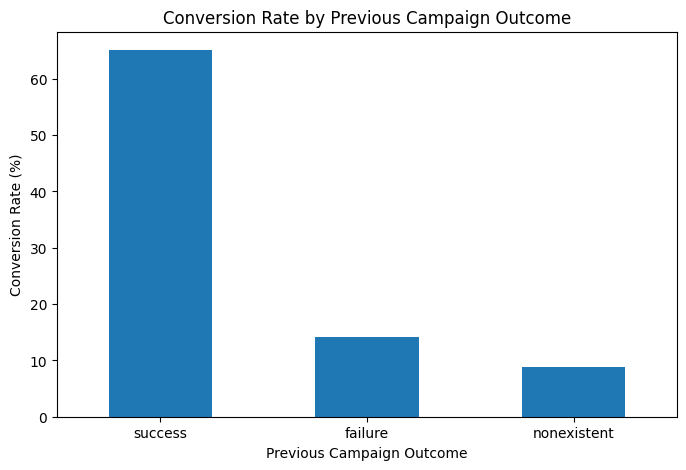

In [20]:
#visualize conversion rates by outcome of previous interactions
plt.figure(figsize=(8,5))
poutcome_summary['conversion_rate'].plot(kind='bar')
plt.title("Conversion Rate by Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Previous Campaign Outcome")
plt.xticks(rotation=0)
plt.show()

In [21]:
#call duration effect
#how does duration of the last call correlate with conversion?
#is there a threshold where longer calls yield better results?

#define duration bins
bins = [0, 100, 200, 400, 600, float('inf')]
labels = ['0-100s','101-200s','201-400s','401-600s','600+']

#create call duration column
df['call_duration'] = pd.cut(df['duration'], bins=bins, labels=labels)

#conversion rate by call duration
duration_summary = (
    df.groupby('call_duration')
    .agg(
        total_contacts=('y', 'count'),
        conversion_rate=('y', lambda x: (x == 'yes').mean() * 100)
    )
    .round(2)
)

duration_summary


,total_contacts,conversion_rate
call_duration,,
0-100s,10020,0.81
101-200s,12727,5.02
201-400s,11261,12.23
401-600s,3700,23.19
600+,3464,48.61


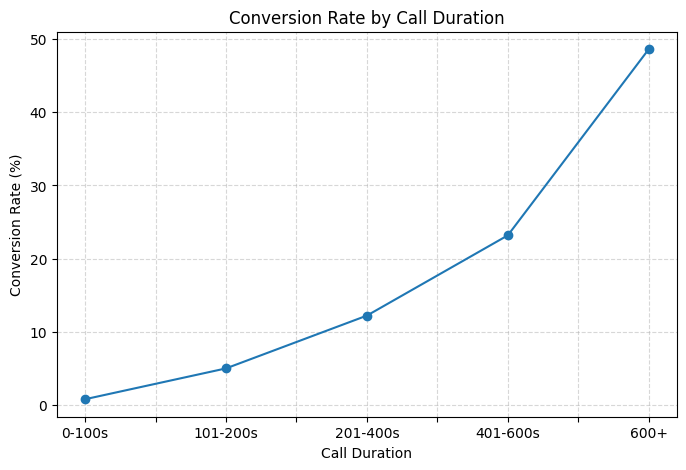

In [22]:
#visualize conversion rate by length of call
plt.figure(figsize=(8,5))
duration_summary['conversion_rate'].plot(marker='o')
plt.title("Conversion Rate by Call Duration")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Call Duration")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [23]:
#number of calls
#how many calls does it take to convert a customer?

#create contact frequency column
df['contact_frequency'] = np.select(
    [
        df['campaign'] == 1,
        df['campaign'] == 2,
        df['campaign'] == 3,
        df['campaign'] == 4,
        df['campaign'] >= 5
    ],
    [
        '1st Call',
        '2nd Call',
        '3rd Call',
        '4th Call',
        '5+ Calls'
    ],
    default='Unknown'
)

#generate frequency summary
frequency_summary = (
    df.groupby('contact_frequency')
    .agg(
        total_contacts=('y', 'count'),
        conversion_rate=('y', lambda x: (x == 'yes').mean() * 100)
    )
    .round(2)
    .sort_index()
)
frequency_summary

,total_contacts,conversion_rate
contact_frequency,,
1st Call,17634,13.04
2nd Call,10568,11.46
3rd Call,5340,10.75
4th Call,2650,9.40
5+ Calls,4984,6.14


In [24]:
frequency_summary = (
    df.groupby('contact_frequency')
    .agg(
        total_contacts=('y', 'count'),
        conversion_rate=('y', lambda x: (x == 'yes').mean() * 100)
    )
    .round(2)
)

frequency_summary

,total_contacts,conversion_rate
contact_frequency,,
1st Call,17634,13.04
2nd Call,10568,11.46
3rd Call,5340,10.75
4th Call,2650,9.40
5+ Calls,4984,6.14


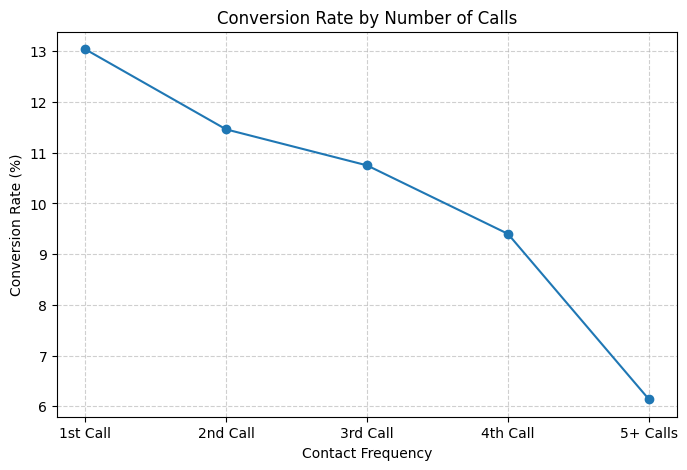

In [25]:
#visualize conversion rate trends as number of calls increase
plt.figure(figsize=(8,5))
plt.plot(frequency_summary.index, frequency_summary['conversion_rate'], 
         marker='o', linestyle='-')
plt.title("Conversion Rate by Number of Calls")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Contact Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [26]:
#output clean dataset to be exported to github 
#clean base copy of dataset 
df_clean = df.copy()
df_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,loan_status,call_duration,contact_frequency
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,No Loan,201-400s,1st Call
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,No Loan,101-200s,1st Call
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,No Loan,201-400s,1st Call
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,No Loan,101-200s,1st Call
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,Has Loan,201-400s,1st Call


In [27]:
#keep only columns that are relevant to dashboard structure
dashboard_cols = [
    #customer profile
    'age', 'job', 'marital', 'education',

    #financial context
    'loan_status', 'default', 'housing',

    #campaign execution
    'contact', 'month', 'day_of_week',

    #engineered features
    'call_duration', 'contact_frequency',

    #prior interaction
    'poutcome', 'pdays',

    #target variable
    'y']

df_final = df_clean[dashboard_cols].copy()

In [28]:
#export clean dataset to csv
df_final.to_csv("bank_marketing_final_dataset.csv", index=False)